### 1. Import packages

In [1]:
import time
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import xgboost as xgb
import joblib
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score, confusion_matrix

import warnings
warnings.filterwarnings("ignore")

from art.estimators.classification import XGBoostClassifier
from art.attacks.evasion import ZooAttack, HopSkipJump

### 2. Load model and test data

In [2]:
# Load trained XGBoost model
xgb_model = joblib.load('../../training/models/framework_xgb_TVAE.pkl')

# Load test data
df_test = pd.read_csv('../../datasets/test_shap_66.csv')
X_test = df_test.drop(columns=['Label']).values
y_test = df_test['Label'].values.astype(int)

In [3]:
# Create ART classifier
classifier = XGBoostClassifier(
    model=xgb_model,
    clip_values=(np.min(X_test), np.max(X_test)),
    nb_features=X_test.shape[1],
    nb_classes=len(np.unique(y_test)),
)

predictions = classifier.predict(X_test)
predictions = np.argmax(predictions, axis=1)
accuracy = accuracy_score(y_test, predictions)
print(f'Original Accuracy: {accuracy * 100:.2f}%')

Original Accuracy: 85.01%


In [4]:
def evaluate_attack(y_test, y_pred, attack_name):
    predictions = np.argmax(y_pred, axis=1)

    accuracy = accuracy_score(y_test, predictions) * 100
    f1 = f1_score(y_test, predictions, average='macro')
    precision = precision_score(y_test, predictions, average='macro') * 100
    recall = recall_score(y_test, predictions, average='macro') * 100

    print(f'--- {attack_name} ---')
    print(f'Accuracy: {accuracy:.2f}%')
    print(f'Precision: {precision:.2f}%')
    print(f'Recall: {recall:.2f}%')
    print(f'F1 Score: {f1:.4f}')

    cm = confusion_matrix(y_test, predictions)
    plt.figure(figsize=(10, 8))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.title(f'{attack_name} - Confusion Matrix')
    plt.xlabel('Predicted Label')
    plt.ylabel('True Label')
    plt.tight_layout()
    plt.show()

### 3. Evaluate original model on adversarial test samples

--- ZOO (before AT) ---
Accuracy: 28.45%
Precision: 28.73%
Recall: 28.45%
F1 Score: 0.2743


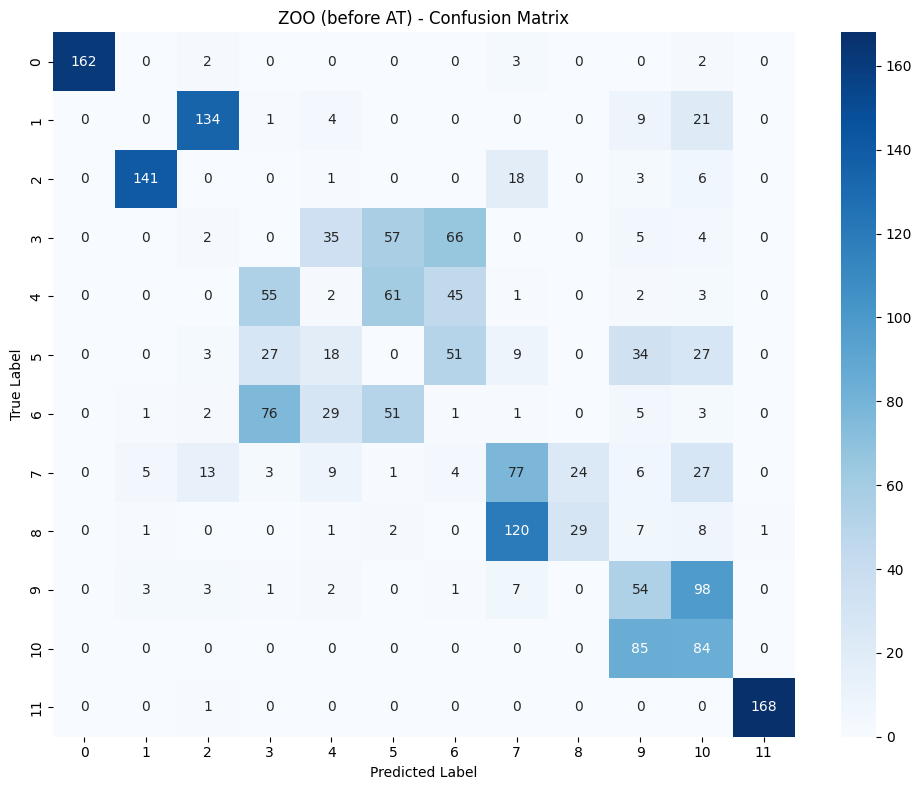

--- HSJA (before AT) ---
Accuracy: 16.91%
Precision: 14.38%
Recall: 16.91%
F1 Score: 0.1183


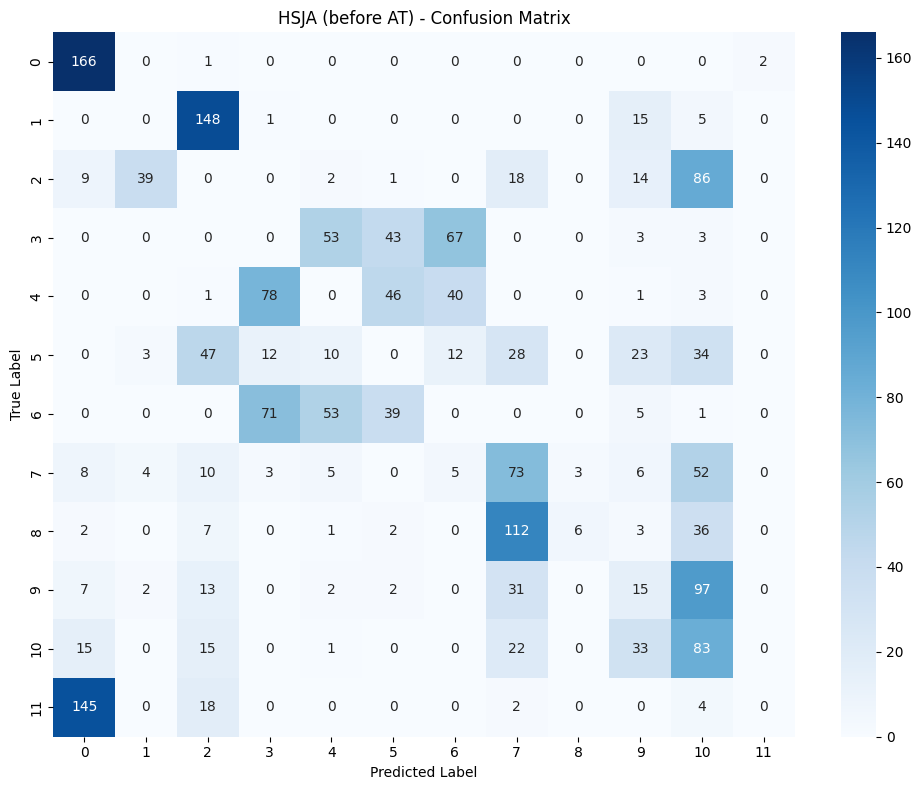

In [5]:
# Load adversarial test samples
df_zoo = pd.read_csv('../../adv_samples/adv_eval/xgb/xgb_zoo_adv.csv')
ZOO_samples = df_zoo.drop(columns=['Label']).values

df_hsja = pd.read_csv('../../adv_samples/adv_eval/xgb/xgb_hsja_adv.csv')
HSJA_samples = df_hsja.drop(columns=['Label']).values

preds_adv = classifier.predict(ZOO_samples)
evaluate_attack(y_test, preds_adv, 'ZOO (before AT)')

preds_adv = classifier.predict(HSJA_samples)
evaluate_attack(y_test, preds_adv, 'HSJA (before AT)')

### 4. Generate adversarial samples from training data

In [6]:
# Load train data
df_train = pd.read_csv('../../datasets/train_tvae.csv')
X_train = df_train.drop(columns=['Label']).values
y_train = df_train['Label'].values.astype(int)

ZOO on train data

In [7]:
attack = ZooAttack(
    classifier=classifier,
    confidence=0.0,
    targeted=False,
    learning_rate=1e-1,
    max_iter=50,
    binary_search_steps=2,
    initial_const=1e-3,
    abort_early=True,
    use_resize=False,
    use_importance=False,
    nb_parallel=10,
    batch_size=1,
    variable_h=0.02,
)

start_time = time.time()
ZOO_train_adv = attack.generate(x=X_train)
print("Runtime: ", time.time() - start_time, " seconds")

# Save
feature_names = df_train.columns[:-1].tolist()
df_adv = pd.DataFrame(ZOO_train_adv, columns=feature_names)
df_adv['Label'] = y_train
df_adv.to_csv('../../adv_samples/adv_training/xgb/xgb_zoo_train_adv.csv', index=False)

ZOO: 100%|██████████| 9600/9600 [31:21<00:00,  5.10it/s]


Runtime:  1883.0707488059998  seconds


HSJA on train data

In [ ]:
attack = HopSkipJump(
    classifier=classifier,
    batch_size=16,
    targeted=False,
    norm=2,
    max_iter=2,
    max_eval=200,
    init_eval=10,
    init_size=10,
    verbose=True,
)

start_time = time.time()
HSJA_train_adv = attack.generate(x=X_train)
print("Runtime: ", time.time() - start_time, " seconds")

# Save
df_adv = pd.DataFrame(HSJA_train_adv, columns=feature_names)
df_adv['Label'] = y_train
df_adv.to_csv('../../adv_samples/adv_training/xgb/xgb_hsja_train_adv.csv', index=False)

### 5. Adversarial training — retrain XGBoost

In [ ]:
# Load adversarial training samples
df_zoo_train = pd.read_csv('../../adv_samples/adv_training/xgb/xgb_zoo_train_adv.csv')
df_hsja_train = pd.read_csv('../../adv_samples/adv_training/xgb/xgb_hsja_train_adv.csv')

ZOO_train_adv = df_zoo_train.drop(columns=['Label']).values
HSJA_train_adv = df_hsja_train.drop(columns=['Label']).values

# Merge: original train + ZOO adv + HSJA adv
adv_samples = np.concatenate((ZOO_train_adv, HSJA_train_adv), axis=0)
train_data = np.concatenate((X_train, adv_samples), axis=0)
train_labels = np.concatenate((y_train, y_train, y_train), axis=0)

print(f'Train data: {train_data.shape}')
print(f'Train labels: {train_labels.shape}')

In [ ]:
# Retrain XGBoost with original hyperparameters
params = {
    'tree_method': 'hist',
    'max_depth': 15,
    'n_estimators': 5000,
    'learning_rate': 0.3,
    'eval_metric': 'mlogloss',
    'objective': 'multi:softmax',
    'booster': 'gbtree',
    'random_state': 42,
}

print('XGBoost adversarial training...')
model = xgb.XGBClassifier(**params)
xgb_model_at = model.fit(train_data, train_labels)
print('Done.')

joblib.dump(xgb_model_at, '../../defense/models/framework_xgb_TVAE_at.pkl')
print('Saved to defense/models/framework_xgb_TVAE_at.pkl')

### 6. Evaluate retrained model

In [ ]:
# Load retrained model
xgb_model_at = joblib.load('../../defense/models/framework_xgb_TVAE_at.pkl')

classifier_at = XGBoostClassifier(
    model=xgb_model_at,
    clip_values=(np.min(X_test), np.max(X_test)),
    nb_features=X_test.shape[1],
    nb_classes=len(np.unique(y_test)),
)

# Evaluate on original test data
preds_orig = classifier_at.predict(X_test)
evaluate_attack(y_test, preds_orig, 'Original (after AT)')

# Evaluate on ZOO adversarial test samples
preds_adv = classifier_at.predict(ZOO_samples)
evaluate_attack(y_test, preds_adv, 'ZOO (after AT)')

# Evaluate on HSJA adversarial test samples
preds_adv = classifier_at.predict(HSJA_samples)
evaluate_attack(y_test, preds_adv, 'HSJA (after AT)')

### 7. ASR comparison

In [ ]:
# Before AT
preds_before = classifier.predict(X_test)
y_pred_before = np.argmax(preds_before, axis=1)
correct_before = np.where(y_test == y_pred_before)[0]

preds_zoo_before = classifier.predict(ZOO_samples)
asr_zoo_before = np.sum(y_pred_before[correct_before] != np.argmax(preds_zoo_before, axis=1)[correct_before]) / len(correct_before) * 100

preds_hsja_before = classifier.predict(HSJA_samples)
asr_hsja_before = np.sum(y_pred_before[correct_before] != np.argmax(preds_hsja_before, axis=1)[correct_before]) / len(correct_before) * 100

# After AT
preds_after = classifier_at.predict(X_test)
y_pred_after = np.argmax(preds_after, axis=1)
correct_after = np.where(y_test == y_pred_after)[0]

preds_zoo_after = classifier_at.predict(ZOO_samples)
asr_zoo_after = np.sum(y_pred_after[correct_after] != np.argmax(preds_zoo_after, axis=1)[correct_after]) / len(correct_after) * 100

preds_hsja_after = classifier_at.predict(HSJA_samples)
asr_hsja_after = np.sum(y_pred_after[correct_after] != np.argmax(preds_hsja_after, axis=1)[correct_after]) / len(correct_after) * 100

print(f'ZOO  ASR: {asr_zoo_before:.2f}% -> {asr_zoo_after:.2f}%')
print(f'HSJA ASR: {asr_hsja_before:.2f}% -> {asr_hsja_after:.2f}%')